Imports and Loading Data

In [1]:
import numpy as np
import pandas as pd 
from pandas import Series, DataFrame
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
df = pd.read_csv('slice_localization_data.csv')

There are no missing values in this dataset as mentioned by UCI. The reason for this is because values from column 2 - column 241 and column 242 - column 385 belong in the histograms they provided. The first histogram is column 2 - column 241 which represents bone structure and the second histogram is column 242 - column 385 which represents air inclusions inside the body. These will be visualized later.  

In [64]:
df_ref_min = df['reference'].min()
df_ref_max = df['reference'].max()
print(df_ref_max)
print(df_ref_min)



97.489115
1.738733


The dataset information given by UCI states that reference values range from 0 - 180 with 0 being the top of the head and 180
being the soles of the feet. In this dataset, after gathering the max and min values of the reference column. 
we can come to the conclusion that the vast majority of the patients had CT slices that were between their head and pelvic region rather having  done full-body scans. 

Exploratory Data Analysis(EDA)


In [65]:
row = df.iloc[0]

bone = row.loc["value0":"value239"]
air = row.loc["value240":"value383"]

For my initial EDA, I selected the first CT  in the dataset and separated its 384 descriptor features into variables Bone (value0–value239) and Air (value240–value383) feature groups. 

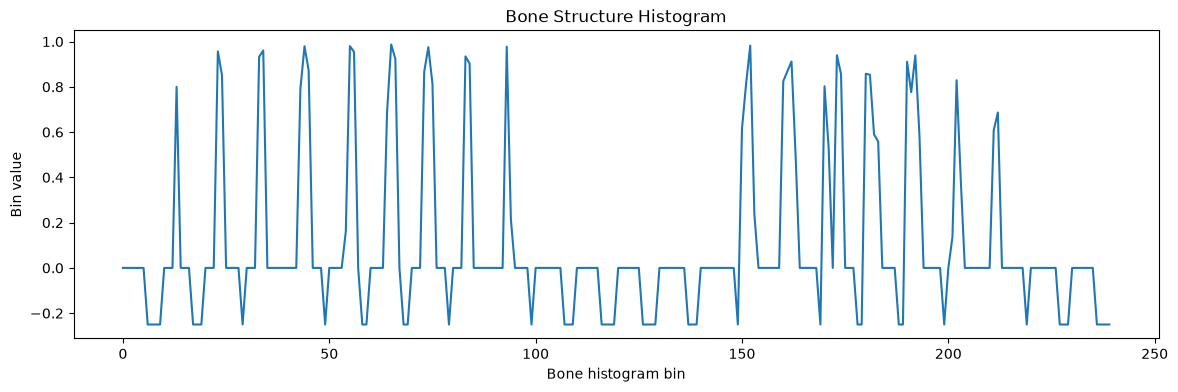

In [66]:
plt.figure(figsize=(14, 4))
plt.plot(bone.values)
plt.xlabel("Bone histogram bin")
plt.ylabel("Bin value")
plt.title("Bone Structure Histogram")
plt.show()

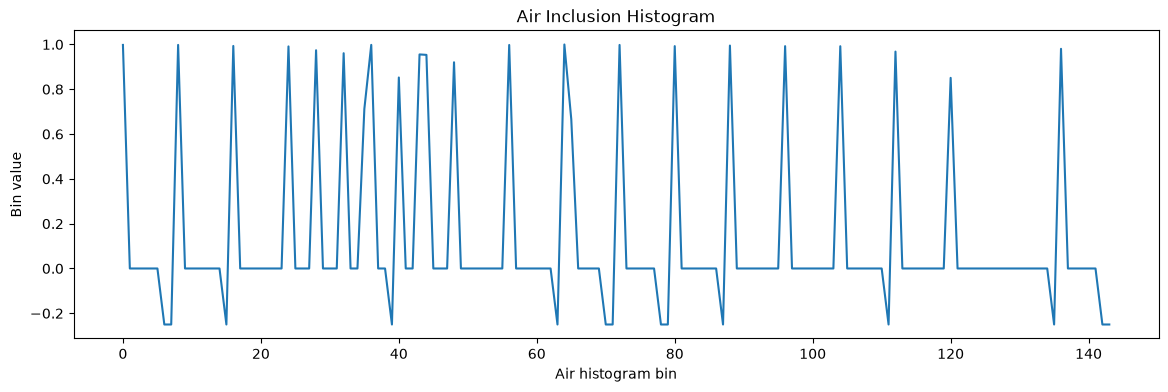

In [67]:
plt.figure(figsize=(14, 4))
plt.plot(air.values)
plt.xlabel("Air histogram bin")
plt.ylabel("Bin value")
plt.title("Air Inclusion Histogram")
plt.show()

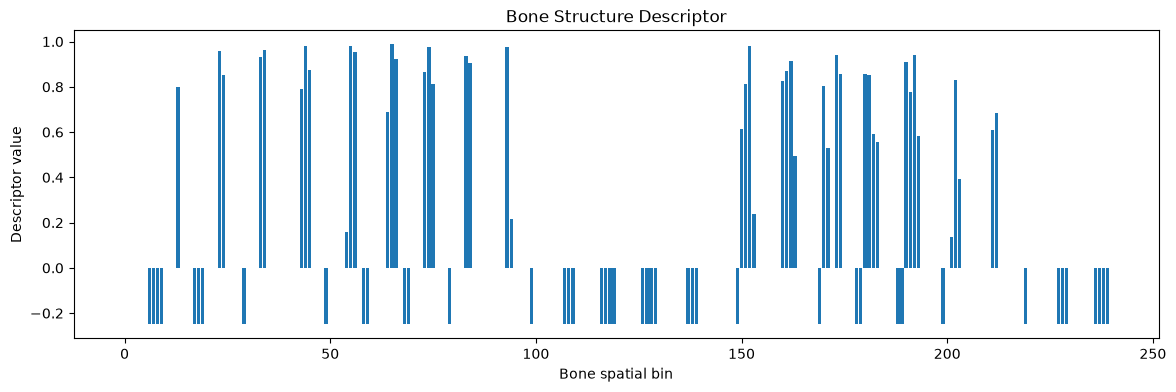

In [68]:
plt.figure(figsize=(14, 4))

plt.bar(range(len(bone)), bone.values)

plt.xlabel("Bone spatial bin")
plt.ylabel("Descriptor value")
plt.title("Bone Structure Descriptor")
plt.show()

This is better for understanding the histogram provided. The values in each column are descriptors and each x-axis position represents a different region in that slice. Therefore, using a histogram wouldn be misleading as the values are not continuous, rather they are independent and using a bar plot would be much more useful. A value closer to 1 means very strong bone feature value and a value of -0.25 means the bin falls outside of the CT Scan image. We can do the same visualization for air inclusion inside the body.

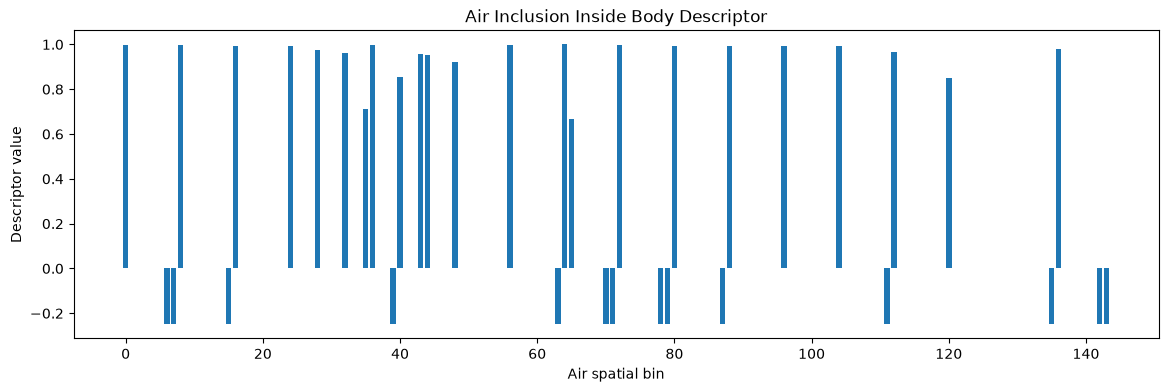

In [69]:
plt.figure(figsize=(14, 4))

plt.bar(range(len(air)), air.values)

plt.xlabel("Air spatial bin")
plt.ylabel("Descriptor value")
plt.title("Air Inclusion Inside Body Descriptor")
plt.show()

We can interpret this in a similar way to the Bone Structure bar plot.

In [70]:
df.head(100)



,patientId,value0,value1,value2,value3,value4,value5,value6,value7,value8,...,value375,value376,value377,value378,value379,value380,value381,value382,value383,reference
0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.980381,0.000000,0.000000,0.000000,0.0,0.0,-0.25,-0.25,21.803851
1,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.000000,0.000000,0.000000,0.0,0.0,-0.25,-0.25,21.745726
2,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.000000,0.000000,0.000000,0.0,0.0,-0.25,-0.25,21.687600
3,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.000000,0.000000,0.000000,0.0,0.0,-0.25,-0.25,21.629474
4,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.976833,0.000000,0.000000,0.000000,0.0,0.0,-0.25,-0.25,21.571348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.00,0.000000,0.999869,0.999965,0.999734,0.0,0.0,0.00,0.00,34.417139
96,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.00,0.000000,0.999886,0.999965,0.999677,0.0,0.0,0.00,0.00,34.300888
97,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.00,0.000000,0.999879,0.999953,0.999713,0.0,0.0,0.00,0.00,34.359013
98,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,-0.25,26.279534


After showing the first 100 rows, we can see that one patient can have multiple reference values that are not similar. To take a better look at the descriptors we can take 3 different reference values that represent the lowest value(closer to top of the head), a value in the middle, and the highest value for that patient(closer to the soles of their feet). 


In [71]:
p0 = df[df['patientId'] == 0]

top_row = p0.loc[p0['reference'].idxmin()]
bottom_row = p0.loc[p0['reference'].idxmax()]

middle_ref = (top_row['reference'] + bottom_row['reference']) / 2
middle_index = (p0['reference'] - middle_ref).abs().idxmin()
middle_row = p0.loc[middle_index]


In [72]:
print("Top:", top_row['reference'])
print("Middle:", middle_row['reference'])
print("Bottom:", bottom_row['reference'])

Top: 5.935522
Middle: 22.850115
Bottom: 39.764708


In [73]:
top_bone = top_row.loc["value0":"value239"]
middle_bone = middle_row.loc["value0":"value239"]
bottom_bone = bottom_row.loc["value0":"value239"]

Now that we have these values for patient 0, we can visualize the bone structure
 and air inclusion histograms for these values and get a better understanding of how these descriptors work. 

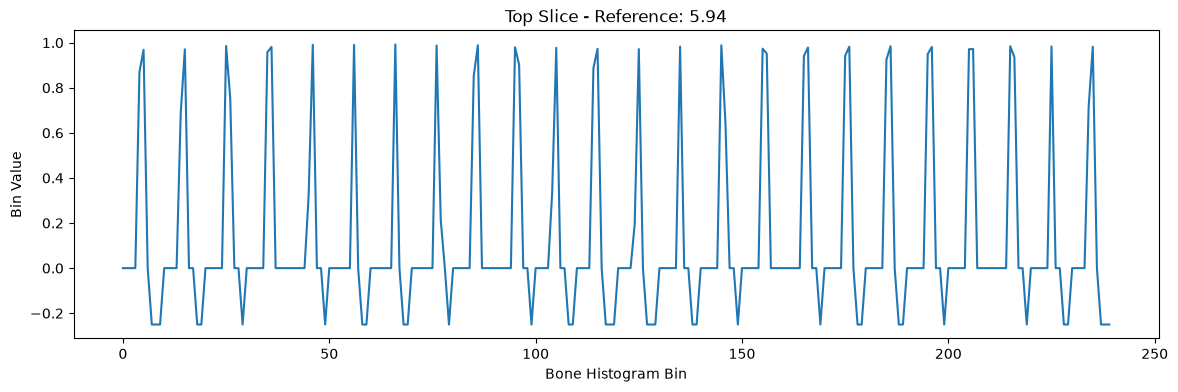

In [74]:
plt.figure(figsize=(14, 4))
plt.plot(top_bone.values)
plt.xlabel("Bone Histogram Bin")
plt.ylabel("Bin Value")
plt.title(f"Top Slice - Reference: {top_row['reference']:.2f}")
plt.show()

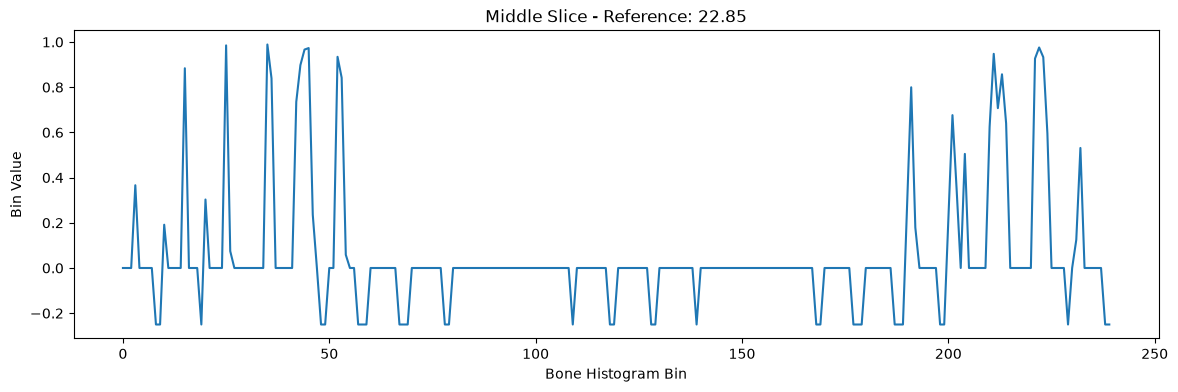

In [75]:
plt.figure(figsize=(14, 4))
plt.plot(middle_bone.values)
plt.xlabel("Bone Histogram Bin")
plt.ylabel("Bin Value")
plt.title(f"Middle Slice - Reference: {middle_row['reference']:.2f}")
plt.show()

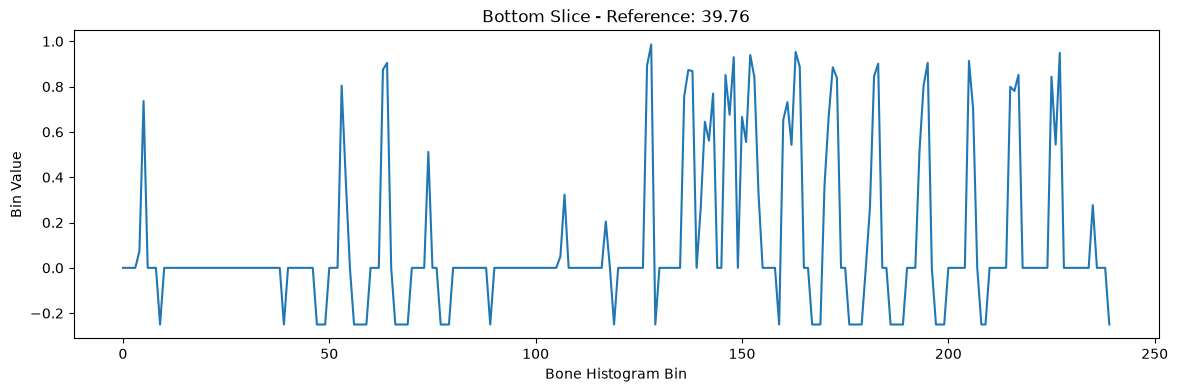

In [76]:
plt.figure(figsize=(14, 4))
plt.plot(bottom_bone.values)
plt.xlabel("Bone Histogram Bin")
plt.ylabel("Bin Value")
plt.title(f"Bottom Slice - Reference: {bottom_row['reference']:.2f}")
plt.show()

For this patient, the Bone descriptor changes noticeably between the minimum, middle, and maximum reference positions. The low-reference slice shows activity distributed across many feature bins, while the middle and high-reference slices show more localized patterns. This suggests that the spatial Bone features vary with axial slice location and may provide useful information for predicting the reference value.

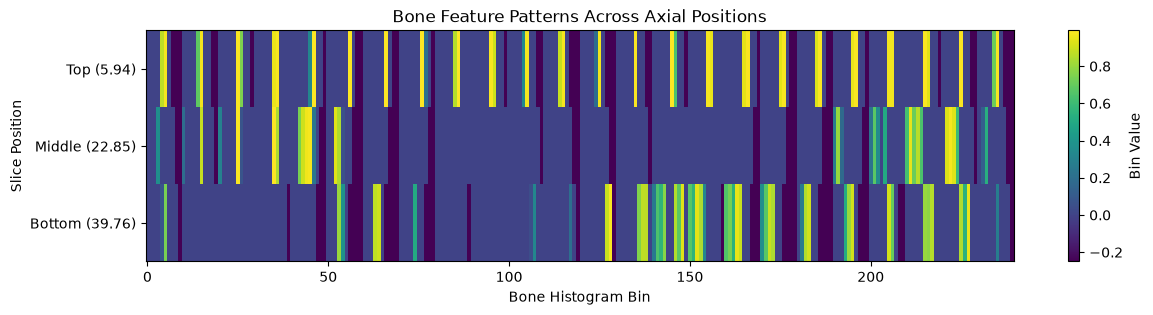

In [77]:
bone_compare = np.array([
    top_bone.values,
    middle_bone.values,
    bottom_bone.values
], dtype=float)

plt.figure(figsize=(14, 3))

plt.imshow(
    bone_compare,
    aspect='auto'
)

plt.yticks(
    [0, 1, 2],
    [
        f"Top ({top_row['reference']:.2f})",
        f"Middle ({middle_row['reference']:.2f})",
        f"Bottom ({bottom_row['reference']:.2f})"
    ]
)

plt.xlabel("Bone Histogram Bin")
plt.ylabel("Slice Position")
plt.title("Bone Feature Patterns Across Axial Positions")

plt.colorbar(label="Bin Value")

plt.show()

This is a heatmap that gives an overall look into the above 3 graphs. 

Now let's take a look at the Air descriptors using the same process. 

In [78]:
top_air = top_row.loc["value242":"value383"]
middle_air = middle_row.loc["value242":"value383"]
bottom_air = bottom_row.loc["value242":"value383"]

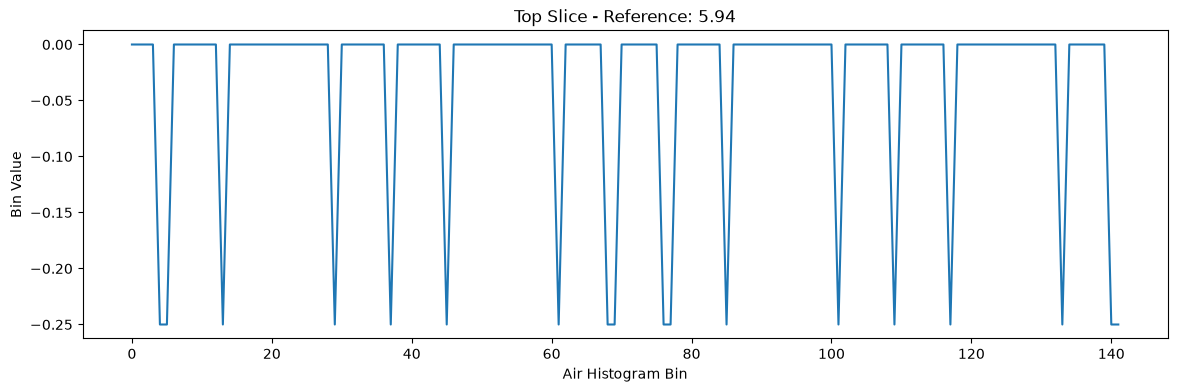

In [79]:
plt.figure(figsize=(14, 4))
plt.plot(top_air.values)
plt.xlabel("Air Histogram Bin")
plt.ylabel("Bin Value")
plt.title(f"Top Slice - Reference: {top_row['reference']:.2f}")
plt.show()

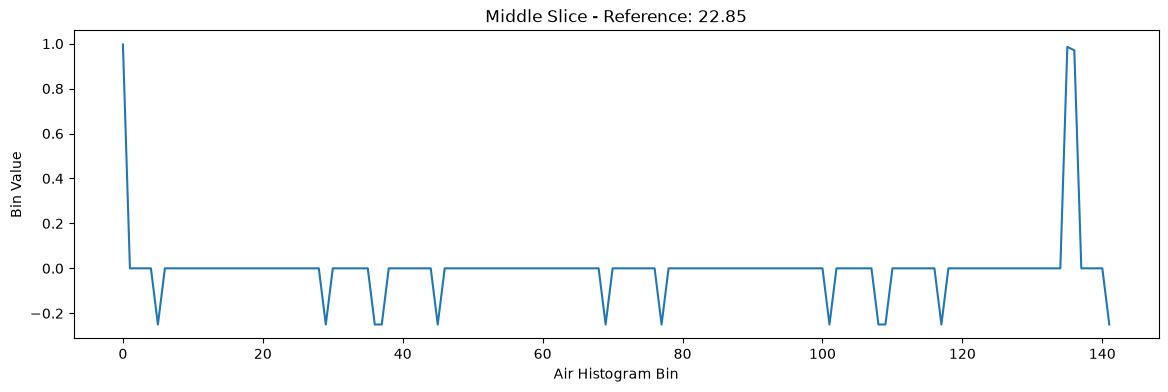

In [80]:
plt.figure(figsize=(14, 4))
plt.plot(middle_air.values)
plt.xlabel("Air Histogram Bin")
plt.ylabel("Bin Value")
plt.title(f"Middle Slice - Reference: {middle_row['reference']:.2f}")
plt.show()

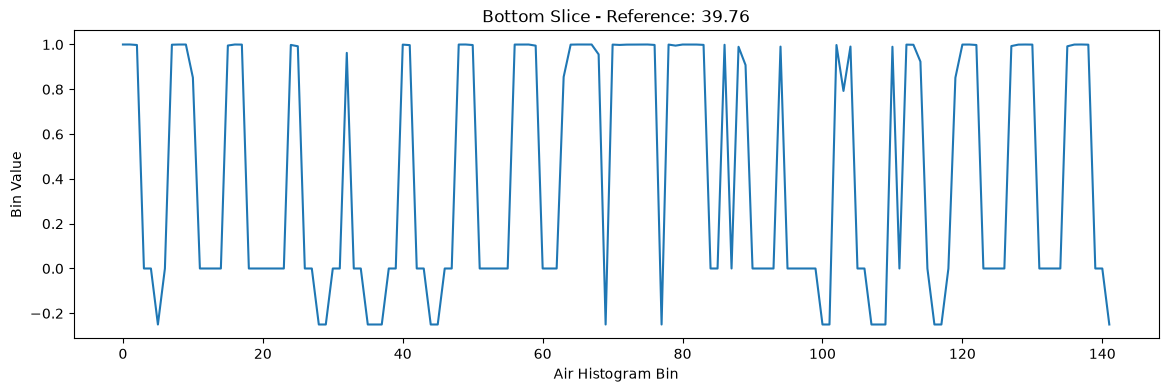

In [81]:
plt.figure(figsize=(14, 4))
plt.plot(bottom_air.values)
plt.xlabel("Air Histogram Bin")
plt.ylabel("Bin Value")
plt.title(f"Bottom Slice - Reference: {bottom_row['reference']:.2f}")
plt.show()

For this patient, Air feature patterns differ strongly across low, middle, and high reference positions. The low-reference slice contains mostly near-zero Air features, the middle slice shows only a few strong activations, and the high-reference slice shows many high-valued Air features across the descriptor. This indicates that the Air spatial features vary with axial location and may help distinguish where a CT slice occurs along the reference axis. 

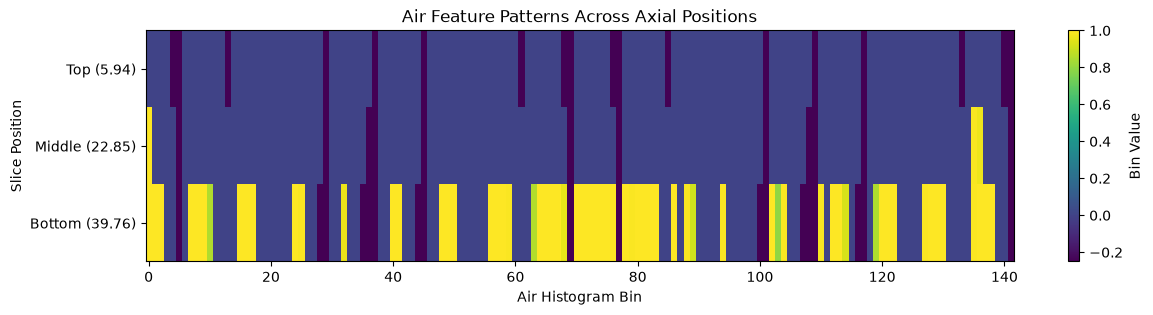

In [82]:
air_compare = np.array([
    top_air.values,
    middle_air.values,
    bottom_air.values
], dtype=float)

plt.figure(figsize=(14, 3))

plt.imshow(air_compare, aspect='auto')

plt.yticks(
    [0, 1, 2],
    [
        f"Top ({top_row['reference']:.2f})",
        f"Middle ({middle_row['reference']:.2f})",
        f"Bottom ({bottom_row['reference']:.2f})"
    ]
)

plt.xlabel("Air Histogram Bin")
plt.ylabel("Slice Position")
plt.title("Air Feature Patterns Across Axial Positions")
plt.colorbar(label="Bin Value")

plt.show()

This is a heatmap that gives an overall look into the above 3 graphs. 

After analyzing one patient's CT slices, I am going to use the knowledge I gained from that analysis to analyze the dataset as a whole. 

In [83]:
patient_info = df.groupby('patientId').agg(slices=('reference', 'count'), min_ref = ('reference', 'min'), max_ref=('reference','max'))
patient_info['ref_range'] = (
    patient_info['max_ref'] - patient_info['min_ref']
)

patient_info.head(10)

,slices,min_ref,max_ref,ref_range
patientId,,,,
0,583,5.935522,39.764708,33.829186
1,578,6.860137,36.560652,29.700515
2,390,7.069820,36.343494,29.273674
3,449,7.944646,39.198289,31.253643
4,461,9.936306,35.104522,25.168216
5,335,8.887078,33.992002,25.104924
6,100,6.317076,37.694812,31.377736
7,447,26.841522,60.520797,33.679275
8,802,27.190588,91.822956,64.632368


This is a summary table to get a better look at the amount of slices each patient has had, the minimum and maximum reference value and the range. The range is max - min which can be understood as how much of the axial axis reference scale is covered on that patient. For example, one patient, A,  has a min of 10 and max of 30, so their range is 20. Another patient, B,  has a min of 5 and a max of 45, so their range is 40. This means that patient B's CT scan covered more of their body than patient A's. 

In [84]:
patient_info.describe()

,slices,min_ref,max_ref,ref_range
count,97.000000,97.000000,97.000000,97.000000
mean,551.546392,19.075414,64.167387,45.091973
std,388.755574,9.980122,25.571417,18.532136
min,66.000000,1.738733,28.615880,19.826071
25%,147.000000,7.943656,37.694812,29.393896
50%,499.000000,24.543973,57.895773,34.517213
75%,807.000000,26.748452,91.814557,64.810006
max,1749.000000,47.549612,97.489115,85.958862


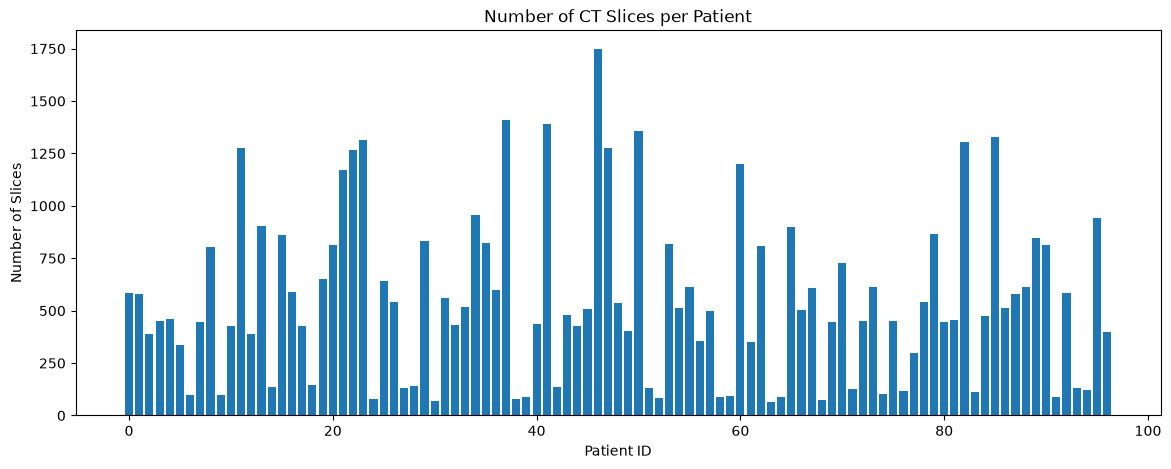

In [85]:
plt.figure(figsize=(14, 5))

plt.bar(
    patient_info.index,
    patient_info['slices']
)

plt.xlabel('Patient ID')
plt.ylabel('Number of Slices')
plt.title('Number of CT Slices per Patient')

plt.show()

Visualizing the number of CT slices per patient shows us that it is very varied. This is not a normal distribution and contains outliers. 

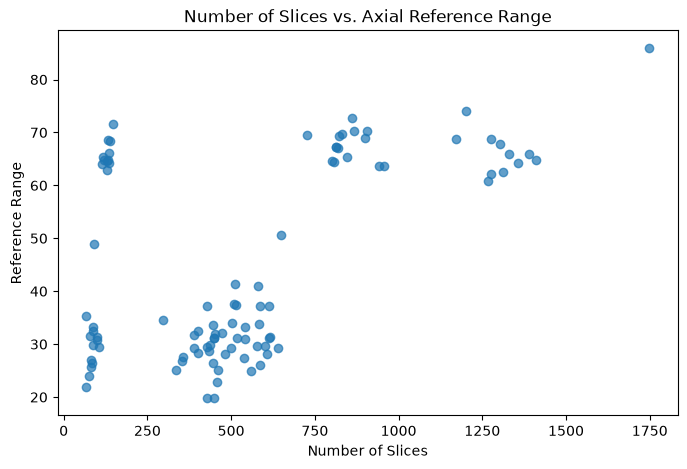

In [87]:
plt.figure(figsize=(8, 5))

plt.scatter(
    patient_info['slices'],
    patient_info['ref_range'],
    alpha=0.7
)

plt.xlabel('Number of Slices')
plt.ylabel('Reference Range')
plt.title('Number of Slices vs. Axial Reference Range')

plt.show()

This is a visualization that I thought was useful because this helps in understanding the relationship between the number of slices and the reference range for the patietns. The number of CT slices is not directly proportional to axial reference range. Patients with similar reference coverage can have substantially different slice counts, suggesting differences in slice sampling density or spacing. The data also forms two broad coverage groups, around 20–40 and 60–70 reference units, indicating substantial variation in scan coverage across patients.

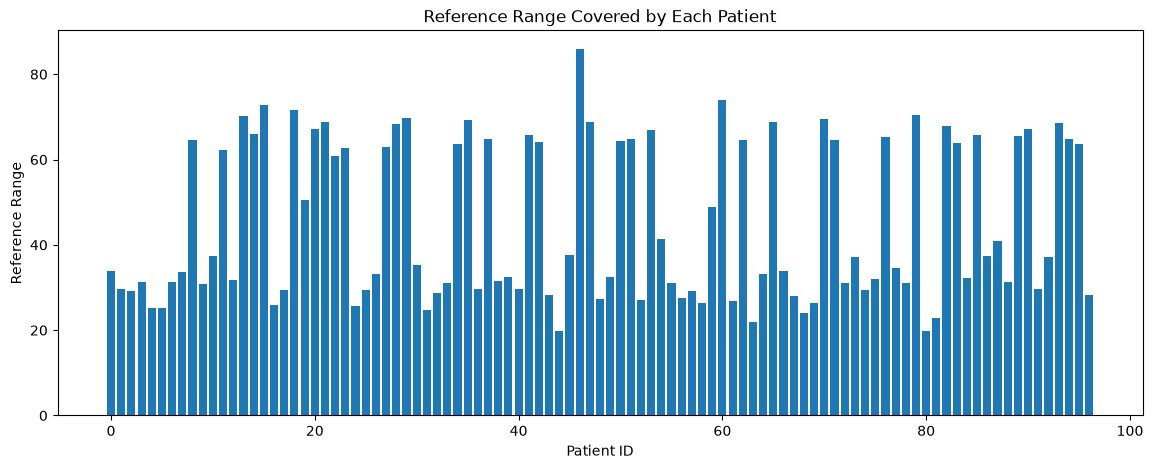

In [88]:
plt.figure(figsize=(14, 5))

plt.bar(
    patient_info.index,
    patient_info['ref_range']
)

plt.xlabel('Patient ID')
plt.ylabel('Reference Range')
plt.title('Reference Range Covered by Each Patient')

plt.show()

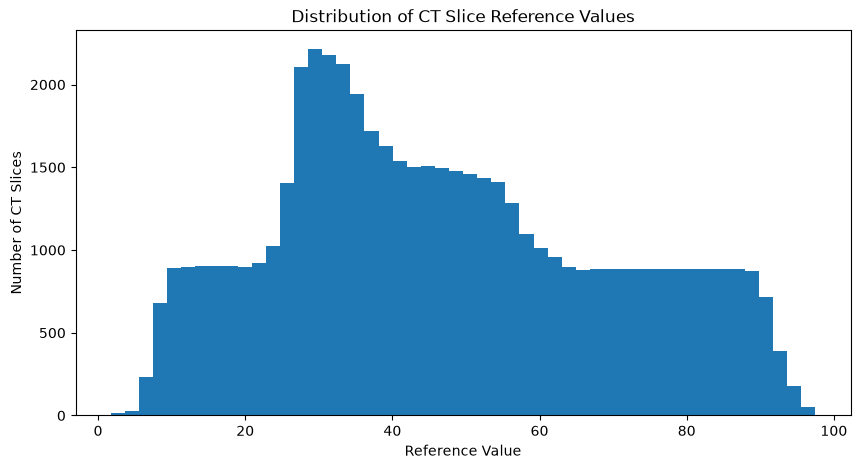

In [89]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['reference'],
    bins=50
)

plt.xlabel('Reference Value')
plt.ylabel('Number of CT Slices')
plt.title('Distribution of CT Slice Reference Values')

plt.show()

In [90]:
patient_info.sort_values(
    'slices',
    ascending=False
).head(10)

,slices,min_ref,max_ref,ref_range
patientId,,,,
46,1749,6.398721,92.357583,85.958862
37,1410,26.193249,91.003255,64.810006
41,1389,26.818977,92.677245,65.858268
50,1358,26.605130,90.927203,64.322073
85,1329,25.761939,91.619976,65.858037
23,1313,28.181184,90.789148,62.607964
82,1303,26.364836,94.130285,67.765449
47,1277,24.111551,92.829758,68.718207
11,1276,27.508115,89.737111,62.228996


In [91]:
patient_info.sort_values(
    'slices'
).head(10)

,slices,min_ref,max_ref,ref_range
patientId,,,,
63,66,8.227581,30.046099,21.818518
30,67,24.462320,59.719074,35.256754
68,75,8.039524,32.061756,24.022232
38,80,8.385218,39.961162,31.575944
24,81,7.937135,33.677586,25.740451
52,83,6.581132,33.568655,26.987523
58,86,8.057332,34.514347,26.457015
39,87,7.335707,39.843587,32.507880
91,87,8.474549,38.220609,29.746060


Now that we analyzed on a patient level, we can look at the entire dataset as a whole and see if these change. 


In [92]:
bone_cols = df.loc[:, "value0":"value239"].columns
air_cols = df.loc[:, "value240":"value383"].columns

In [93]:
bone_corr = df[list(bone_cols) + ['reference']].corr()['reference'].drop('reference')
air_corr = df[list(air_cols) + ['reference']].corr()['reference'].drop('reference')

Text(0.5, 1.0, 'Bone Feature Correlation with Axial Reference')

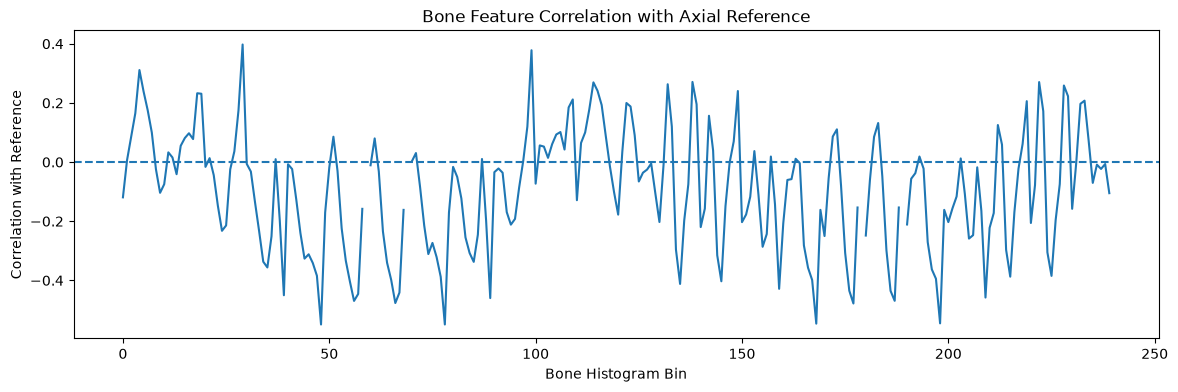

In [94]:
plt.figure(figsize=(14, 4))

plt.plot(range(len(bone_corr)), bone_corr.values)

plt.axhline(0, linestyle='--')
plt.xlabel("Bone Histogram Bin")
plt.ylabel("Correlation with Reference")
plt.title("Bone Feature Correlation with Axial Reference")


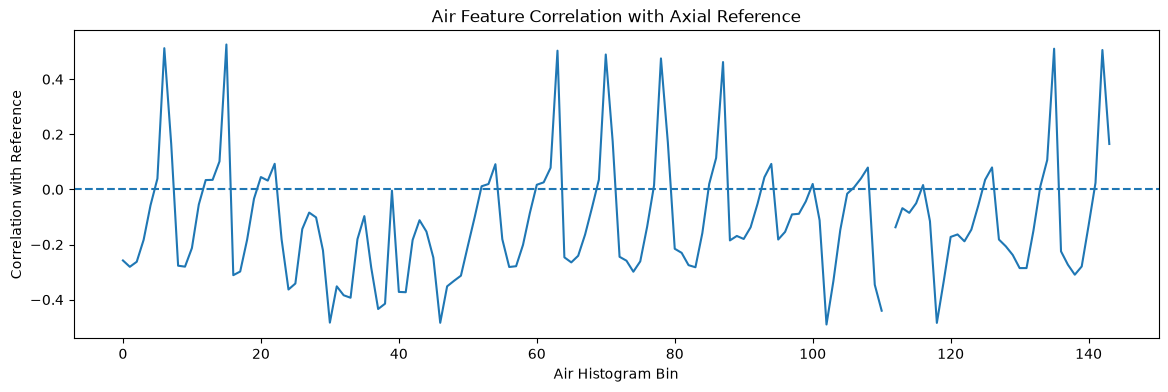

In [95]:
plt.figure(figsize=(14, 4))

plt.plot(range(len(air_corr)), air_corr.values)

plt.axhline(0, linestyle='--')
plt.xlabel("Air Histogram Bin")
plt.ylabel("Correlation with Reference")
plt.title("Air Feature Correlation with Axial Reference")

plt.show()

In [96]:
bone_corr.abs().sort_values(ascending=False).head(10)

value78     0.549170
value48     0.549170
value168    0.546260
value198    0.545324
value177    0.478173
value66     0.476576
value56     0.469432
value187    0.469141
value89     0.459867
value209    0.458037
Name: reference, dtype: float64

In [97]:
air_corr.abs().sort_values(ascending=False).head(10)

value255    0.525858
value246    0.512513
value375    0.510589
value382    0.505857
value303    0.503405
value342    0.490152
value310    0.489581
value358    0.484308
value286    0.483934
value270    0.483354
Name: reference, dtype: float64

In [98]:
feature_cols = df.loc[:, "value0":"value383"].columns

X = df[feature_cols]
y = df["reference"]

In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [100]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [101]:
print("PCA Explained Variance")
print("----------------------")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.2f}%")
print(f"Total: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

PCA Explained Variance
----------------------
PC1: 14.86%
PC2: 12.11%
Total: 26.96%


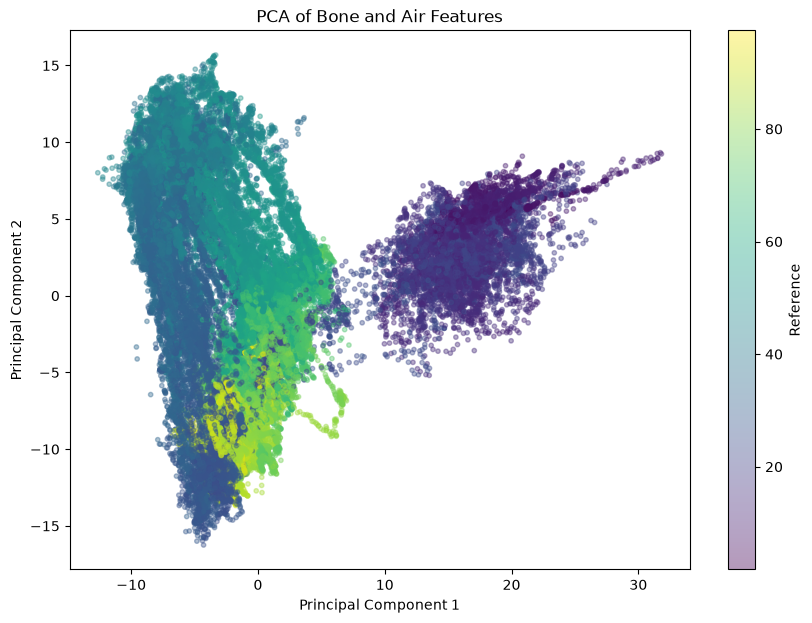

In [102]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=10,
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Bone and Air Features")

plt.colorbar(scatter, label="Reference")

plt.show()

The PCA we did here reduced the columns that contained bone and air features into two components which explain a total of 27% of the variance. This is generally a low varaince percentage, however, for this dataset and the goal of this project that is okay. Even with 

In [103]:
groups = df["patientId"]

In [104]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

We are going to split by patients using GroupShuffleSplit. This is because we do not want the same patient to be in the both the training and testing dataset. This is due to the fact that we need to have our model predict on completley new patients so having no data leakage and true generalization is important. 


In [105]:
print("Training slices:", len(X_train))
print("Testing slices:", len(X_test))

print(
    "Training patients:",
    df.iloc[train_idx]["patientId"].nunique()
)

print(
    "Testing patients:",
    df.iloc[test_idx]["patientId"].nunique()
    
)

Training slices: 43338
Testing slices: 10162
Training patients: 77
Testing patients: 20


This shows how the training and testing sets were split. It shows how many patients and slices in each set. Next we need to confirm that there was no overlap of patient data. 

In [106]:
train_patients = set(
    df.iloc[train_idx]["patientId"]
)

test_patients = set(
    df.iloc[test_idx]["patientId"]
)

print(
    "Patient overlap:",
    train_patients.intersection(test_patients)
)

Patient overlap: set()


A value of set() confirms that there was no overlap of patient data in our split. 

In [107]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

We are going to be using a pipeline for every model. Prior to training we will use StandardScaler to standardize the sets. Then we we can fit the model and then predict it. 

In [108]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("----------------")
print(f"MAE:  {linear_mae:.3f}")
print(f"RMSE: {linear_rmse:.3f}")
print(f"R²:   {linear_r2:.3f}")

Linear Regression
----------------
MAE:  6.500
RMSE: 9.029
R²:   0.824


The MAE here means that the model's predicted reference position is about 6.5 units off on average. The RMSE is similar to MAE, however, it punishes error much more so we would want a lower value for the RMSE(preferrable a value that is close to or equal to the MAE). Ideally we would want a lower MAE as well as a RMSE, but we would want the RMSE to be close to the MAE value. For the R-squared value here means that the model explains around 82.4% of the variance in the reference values in the test set. For this a higher number is better, so a R-squared value of .824 is good. 

The Linear Regression model was the baseline for all the other models we are going to explore. 

The next model we are going to do is a Ridge Regression. This is because this dataset is highly correlated and has obvious multi-collinearity from the EDA we have performed earlier. 

In [109]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

group_cv = GroupKFold(n_splits=5)

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=group_cv,
    scoring="neg_mean_absolute_error"
)

grid.fit(
    X_train,
    y_train,
    groups=df.iloc[train_idx]["patientId"]
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

In [110]:
print("Best alpha:", grid.best_params_["ridge__alpha"])

Best alpha: 1000


In [111]:
print("Best CV MAE:", -grid.best_score_)

Best CV MAE: 7.7331689063469895


In [112]:
best_ridge = grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

In [113]:
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("----------------")
print(f"Ridge MAE: {ridge_mae:.3f}")
print(f"Ridge RMSE: {ridge_rmse:.3f}")
print(f"Ridge R²: {ridge_r2:.3f}")

Ridge Regression
----------------
Ridge MAE: 6.436
Ridge RMSE: 8.929
Ridge R²: 0.828


A similar process with the pipelines was used here with the ridge regression. For the reguralization penalty, I had to do some calculating to get the best alpha value to use. After that, the ridge regression model produced very similar to linear regression, with a small improvement in MAE and R². This suggests that regularization provides some benefit, but the underlying linear relationship remains largely unchanged. 

Let's now create a Elastic Net model to follow the ridge regression model from before. This is because we can now use L1 regularization combined with the L2 regularization that we had with ridge regression.

In [114]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, GroupKFold

elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(max_iter=5000))
])

param_grid = {
    "elastic__alpha": [0.01, 0.1, 1],
    "elastic__l1_ratio": [0.1, 0.5, 0.9]
}

group_cv = GroupKFold(n_splits=3)

elastic_grid = GridSearchCV(
    elastic_pipeline,
    param_grid,
    cv=group_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

elastic_grid.fit(
    X_train,
    y_train,
    groups=df.iloc[train_idx]["patientId"]
)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'elastic__alpha': [0.01, 0.1, ...], 'elastic__l1_ratio': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examp

In [115]:
best_l1 = elastic_grid.best_params_["elastic__l1_ratio"]
best_l2 = 1 - best_l1

print("Best alpha:", elastic_grid.best_params_["elastic__alpha"])
print("Best L1 ratio:", best_l1)
print("Best L2 ratio:", best_l2)

Best alpha: 1
Best L1 ratio: 0.1
Best L2 ratio: 0.9


In [116]:
best_elastic = elastic_grid.best_estimator_

elastic_pred = best_elastic.predict(X_test)

In [117]:
best_elastic = elastic_grid.best_estimator_

elastic_pred = best_elastic.predict(X_test)

elastic_mae = mean_absolute_error(y_test, elastic_pred)

elastic_rmse = np.sqrt(
    mean_squared_error(y_test, elastic_pred)
)

elastic_r2 = r2_score(y_test, elastic_pred)

print(f"Elastic Net MAE:  {elastic_mae:.3f}")
print(f"Elastic Net RMSE: {elastic_rmse:.3f}")
print(f"Elastic Net R²:   {elastic_r2:.3f}")

Elastic Net MAE:  6.638
Elastic Net RMSE: 9.280
Elastic Net R²:   0.814


In [118]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)


KeyboardInterrupt: 

In [ ]:
rf_pred = rf_pipeline.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE:  {rf_mae:.3f}")
print(f"Random Forest RMSE: {rf_rmse:.3f}")
print(f"Random Forest R²:   {rf_r2:.3f}")

Random Forest MAE:  2.696
Random Forest RMSE: 6.216
Random Forest R²:   0.916


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Elastic Net",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        elastic_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        elastic_rmse,
        rf_rmse
    ],
    "R²": [
        linear_r2,
        ridge_r2,
        elastic_r2,
        rf_r2
    ]
}) 

results.round(3)

,Model,MAE,RMSE,R²
0,Linear Regression,6.500,9.029,0.824
1,Ridge Regression,6.436,8.929,0.828
2,Elastic Net,6.638,9.280,0.814
3,Random Forest,2.696,6.216,0.916
